In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
train_df = pd.read_parquet("./train.parquet")
test_df = pd.read_parquet("./test.parquet")

# EDA

In [5]:
print(f"Unique codes: {train_df['code'].nunique()}")
print(f"Unique sub_codes: {train_df['sub_code'].nunique()}")
print(f"Unique sub_categories: {train_df['sub_category'].nunique()}")
print(f"Unique horizons: {train_df['horizon'].nunique()}")
print(f"Value count of horizons:  \n{train_df['horizon'].value_counts()}")

Unique codes: 23
Unique sub_codes: 180
Unique sub_categories: 5
Unique horizons: 4
Value count of horizons:  
horizon
1     1394653
3     1385816
10    1337236
25    1219709
Name: count, dtype: int64


In [9]:
missing_prop = train_df.isnull().sum() / len(train_df) * 100
missing_props = missing_prop[missing_prop > 0].sort_values(ascending=False)
missing_props

feature_at    12.471882
feature_by    11.019194
feature_ay     8.541964
feature_cd     7.496402
feature_ce     5.167840
feature_cf     4.428905
feature_al     4.223319
feature_aw     3.844446
feature_bz     2.842613
feature_bi     2.762237
feature_i      1.105873
feature_k      1.105873
feature_h      1.095381
feature_j      1.095381
feature_cg     0.742757
feature_av     0.724208
feature_au     0.720330
feature_ax     0.719618
feature_m      0.715140
feature_az     0.209034
feature_bl     0.209034
feature_ad     0.166860
feature_n      0.166860
feature_r      0.166860
feature_ag     0.152246
feature_aj     0.152246
feature_ae     0.152246
feature_af     0.152246
feature_ak     0.152246
feature_q      0.133435
feature_ac     0.133435
feature_u      0.133435
feature_p      0.119196
feature_t      0.119196
feature_ab     0.119196
feature_o      0.117248
feature_s      0.117248
feature_y      0.115861
feature_w      0.115861
feature_z      0.115861
feature_x      0.115861
feature_v      0

In [15]:
sum_of_wight_per_horizon = train_df['weight'].groupby(by=train_df['horizon']).sum()
avg_of_wight_per_horizon = train_df['weight'].groupby(by=train_df['horizon']).mean()
sum_of_wight_per_horizon, avg_of_wight_per_horizon

(horizon
 1     2.327173e+13
 3     3.279439e+13
 10    1.571293e+13
 25    1.590335e+13
 Name: weight, dtype: float64,
 horizon
 1     1.668640e+07
 3     2.366432e+07
 10    1.175030e+07
 25    1.303864e+07
 Name: weight, dtype: float64)

okay so, lets focus on group 2(3) for improvement as this is going to affect the evaluation metric the most

In [21]:
train_df.describe()

,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,...,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
count,5.337414e+06,5.337414e+06,5.337414e+06,5.337414e+06,5.337414e+06,5.337414e+06,5.337414e+06,5.337414e+06,5.337414e+06,5.278949e+06,...,5.337374e+06,5.337414e+06,5.334779e+06,4.937300e+06,5.061585e+06,5.101025e+06,5.297770e+06,5.337414e+06,5.337414e+06,5.337414e+06
mean,9.258638e+00,1.963320e+03,8.868155e+01,8.567391e+00,8.564846e+00,8.565059e+00,8.562926e+00,8.564357e+00,8.566521e+00,5.912386e-03,...,-2.811133e-01,-1.781311e-01,-4.609584e-01,-8.239401e-01,-2.288152e-02,1.472680e+00,1.062790e+00,2.323426e+00,-6.659048e-01,1.642788e+07
std,9.206252e+00,9.970220e+02,5.603141e+01,4.869982e+00,4.869406e+00,4.871465e+00,4.870096e+00,4.868880e+00,4.868368e+00,7.923729e-03,...,1.081776e+00,5.281133e-01,1.667862e+00,3.243581e+00,1.728989e-01,1.491990e+00,1.303983e+00,2.092968e+00,3.252764e+01,6.027074e+09
min,1.000000e+00,1.000000e+00,0.000000e+00,1.300042e-01,1.300016e-01,1.300009e-01,1.300028e-01,1.300075e-01,1.300021e-01,0.000000e+00,...,-9.311414e+01,-3.690332e+01,-1.346736e+02,-2.475901e+02,-7.684573e+00,6.128199e-03,1.606530e-02,0.000000e+00,-2.201882e+03,0.000000e+00
25%,1.000000e+00,1.148000e+03,4.000000e+01,4.350043e+00,4.350582e+00,4.346282e+00,4.346104e+00,4.347559e+00,4.348113e+00,3.744142e-04,...,-1.023971e-01,-1.325353e-01,-6.327619e-02,-1.022825e-01,-4.320754e-02,1.173612e-01,8.029312e-02,1.000000e+00,-1.290776e-01,1.553378e+01
50%,3.000000e+00,2.036000e+03,8.400000e+01,8.568381e+00,8.563840e+00,8.567354e+00,8.560350e+00,8.564697e+00,8.565921e+00,1.308027e-03,...,-1.306394e-02,-1.727560e-02,-1.316598e-02,-1.568063e-03,-1.886561e-03,1.197156e+00,1.594703e-01,2.000000e+00,-5.774818e-04,1.699384e+03
75%,1.000000e+01,2.814000e+03,1.330000e+02,1.278265e+01,1.278253e+01,1.278491e+01,1.278212e+01,1.278137e+01,1.278288e+01,1.047050e-02,...,-3.128947e-04,-2.017864e-04,-1.610013e-03,-5.537199e-04,1.675410e-02,2.524100e+00,1.991925e+00,3.000000e+00,5.106807e-02,1.641908e+05
max,2.500000e+01,3.601000e+03,2.130000e+02,1.700000e+01,1.700000e+01,1.700000e+01,1.700000e+01,1.700000e+01,1.700000e+01,1.109517e-01,...,0.000000e+00,-1.733807e-10,-9.195158e-11,4.884884e-05,2.642112e+00,1.363492e+01,1.056441e+01,1.000000e+01,2.314411e+03,1.391222e+13


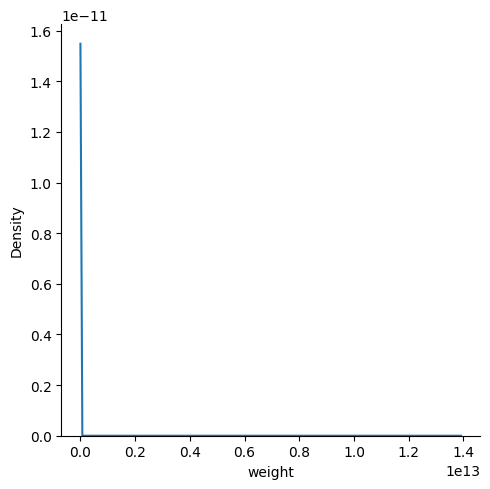

In [20]:
sns.displot(train_df['weight'], kind='kde')

majority is around 0, max is around 1.4. 

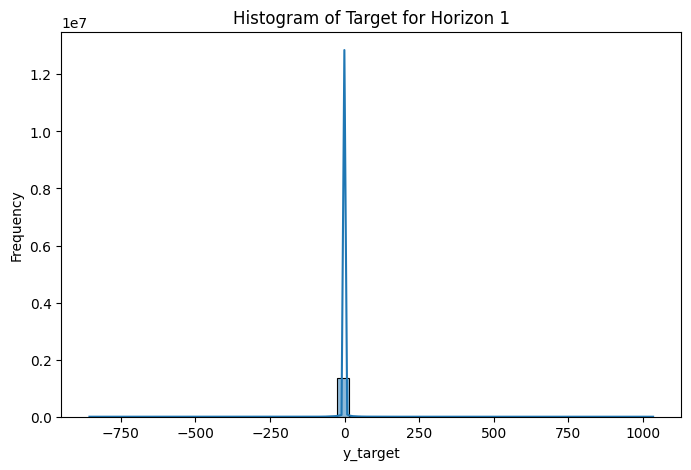

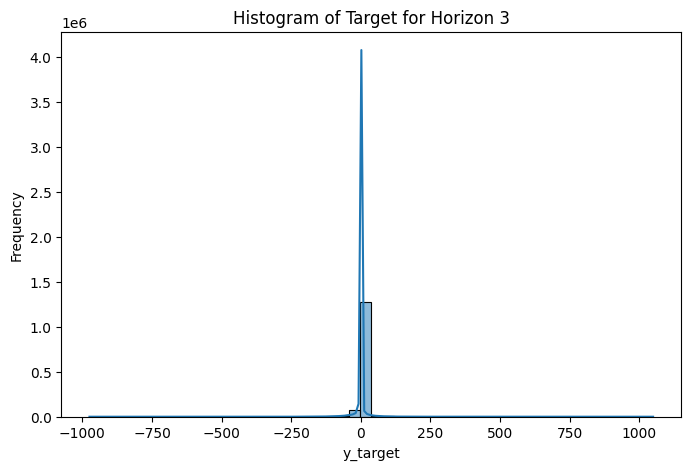

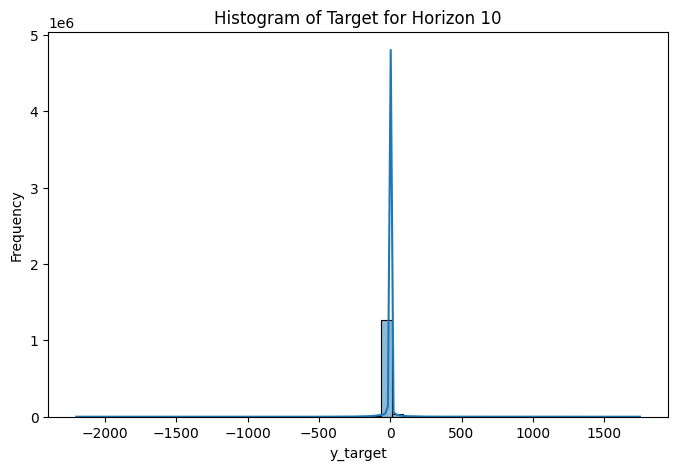

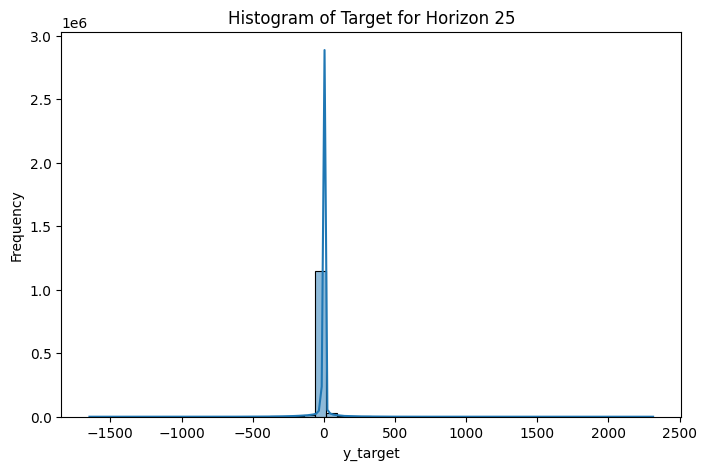

In [32]:
horizons = sorted(train_df['horizon'].unique())

for h in horizons:
    plt.figure(figsize=(8, 5))
    subset = train_df[train_df['horizon'] == h]
    
    sns.histplot(subset['y_target'], bins=50, kde=True)
    plt.title(f'Histogram of Target for Horizon {h}')
    plt.xlabel('y_target')
    plt.ylabel('Frequency')
    plt.show()


In [24]:
corr_train_df = train_df.drop(columns=['id', 'code', 'sub_code', 'sub_category', 'ts_index'])

In [54]:
def split_df_according_to_patterns(df: pd.DataFrame, pattern: str):
    relevant_columns = ['y_target', 'horizon', 'weight']
    if pattern:
        required_columns = df.filter(regex=pattern, axis=1).columns
    else:
        required_columns = df.columns
    all_columns = required_columns.union(relevant_columns)
    new_df = df[all_columns]
    
    feature_corr_by_horizon = new_df.groupby(new_df['horizon']).corr(method='spearman')
    horizons = feature_corr_by_horizon.index.get_level_values('horizon').unique()
    for h in horizons:
        subset = feature_corr_by_horizon.xs(h, level='horizon')  # slice by primary index
        
        plt.figure(figsize=(16, 10))
        sns.heatmap(subset, annot=True, cmap='viridis', fmt=".1f")
        plt.title(f"Heatmap for horizon = {h}")
        plt.show()
    return df[all_columns]

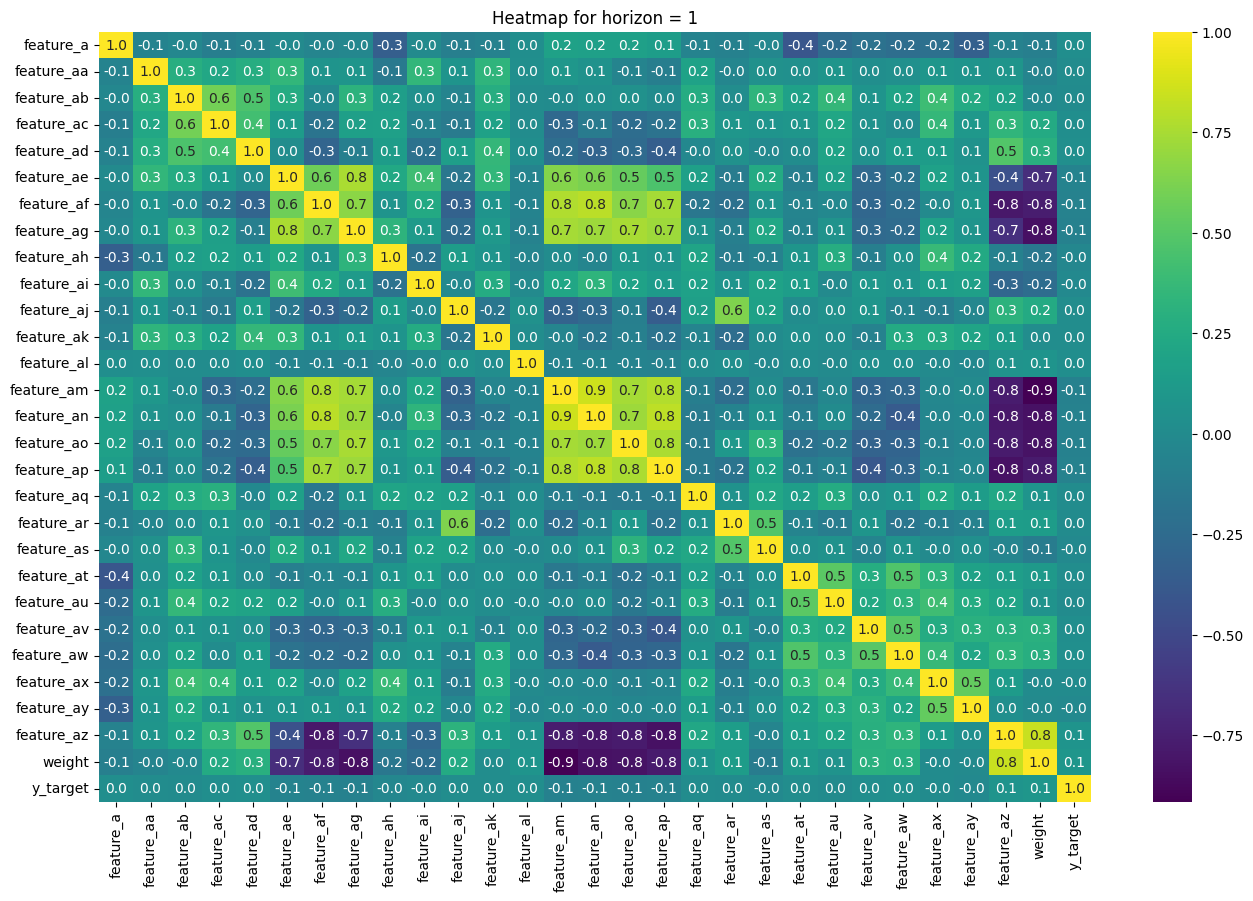

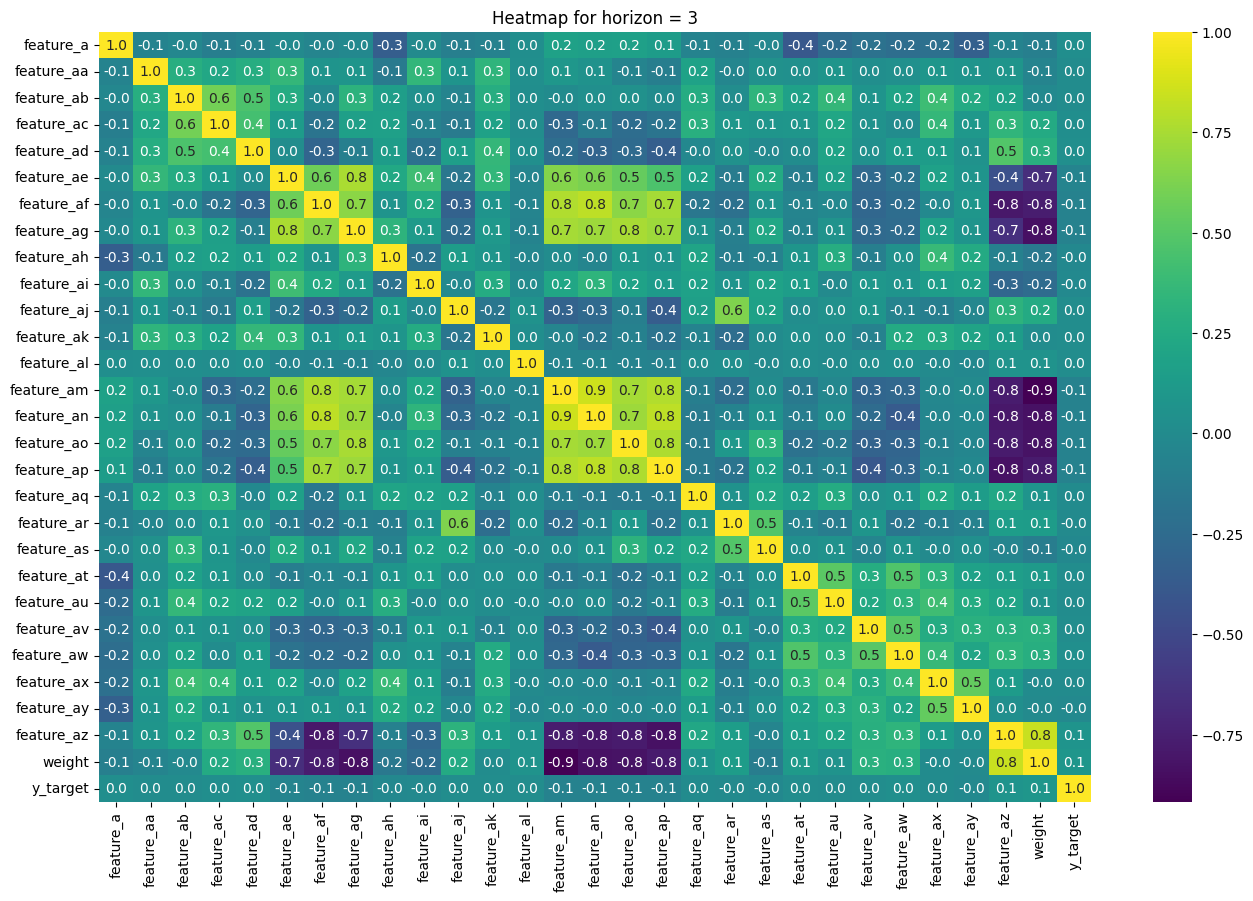

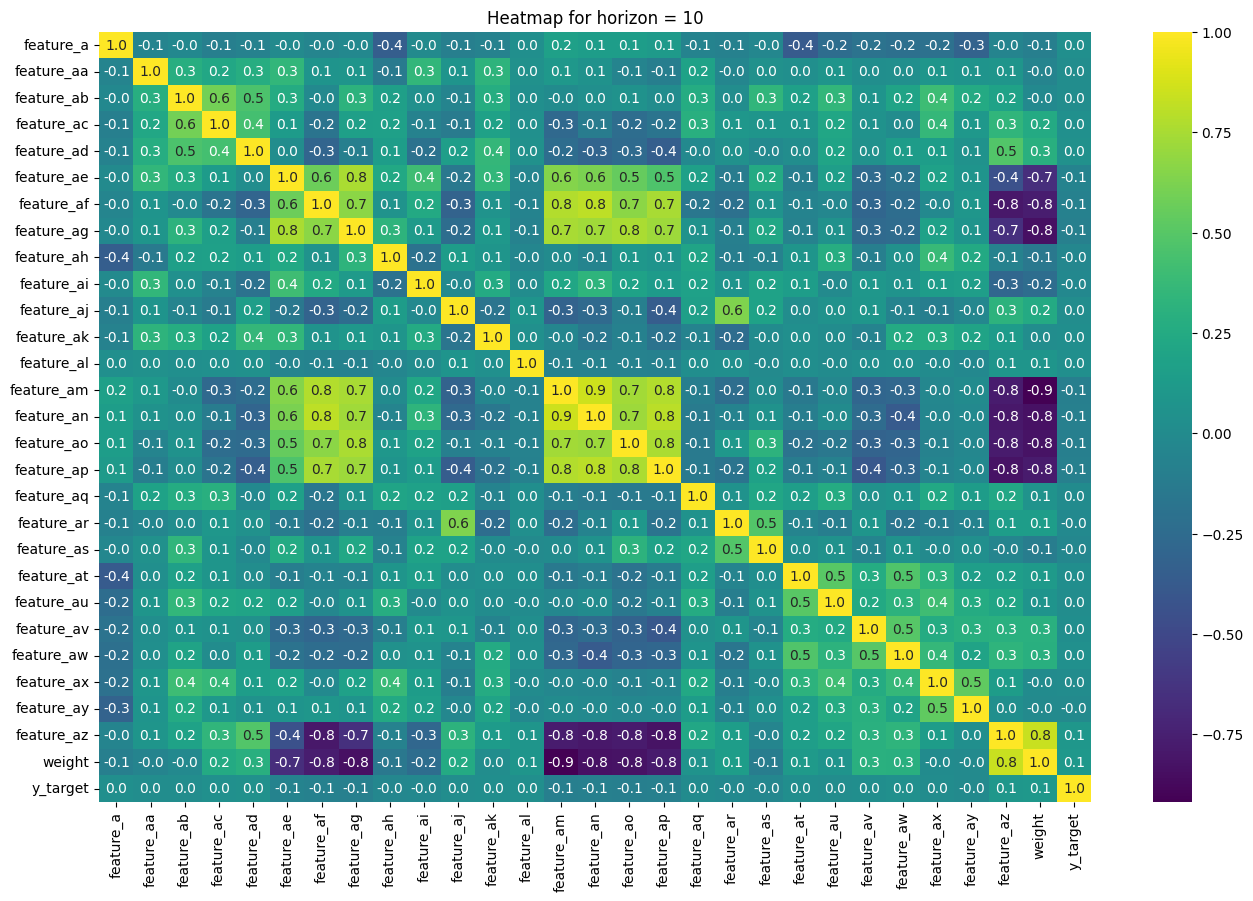

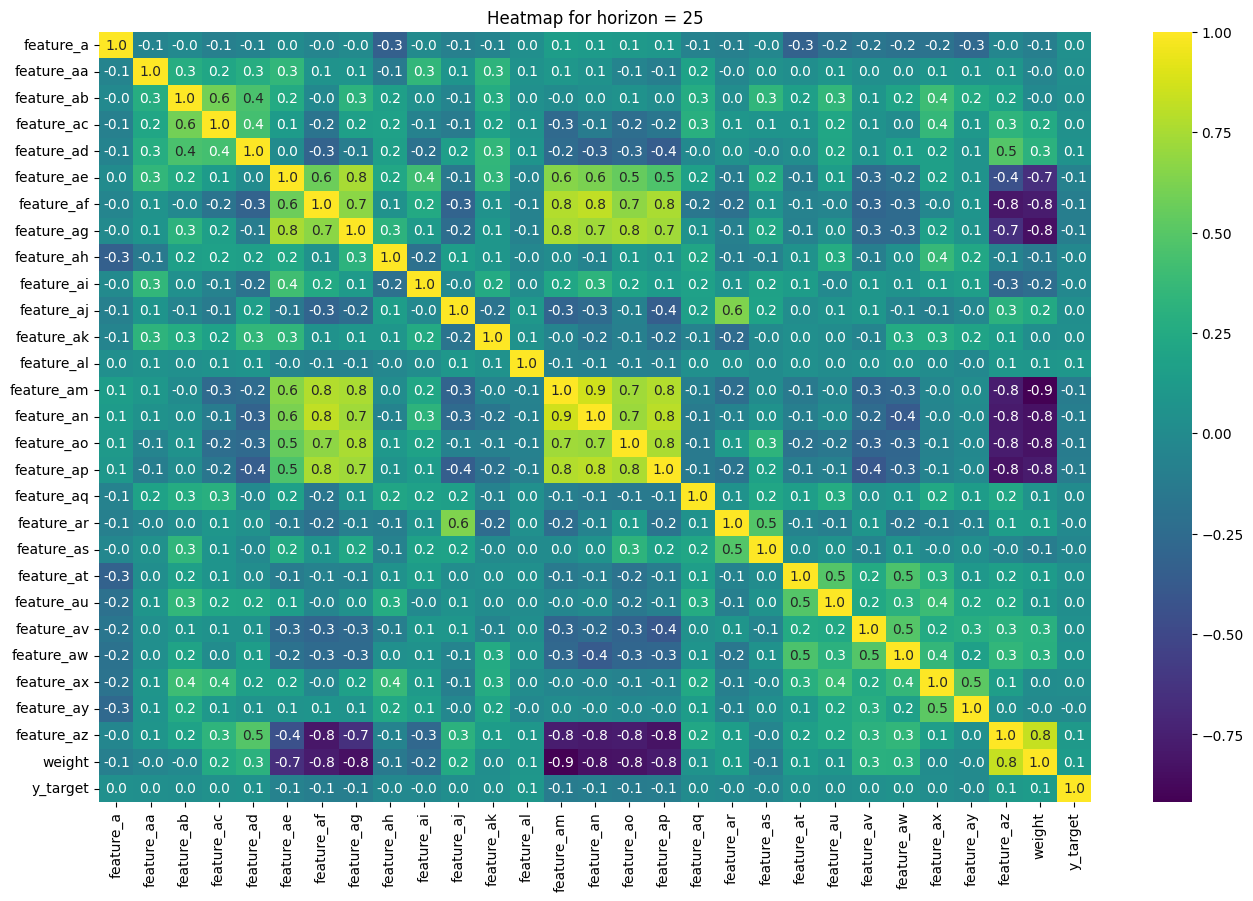

In [49]:
feature_a_df = split_df_according_to_patterns(df= corr_train_df, pattern="^feature_a")

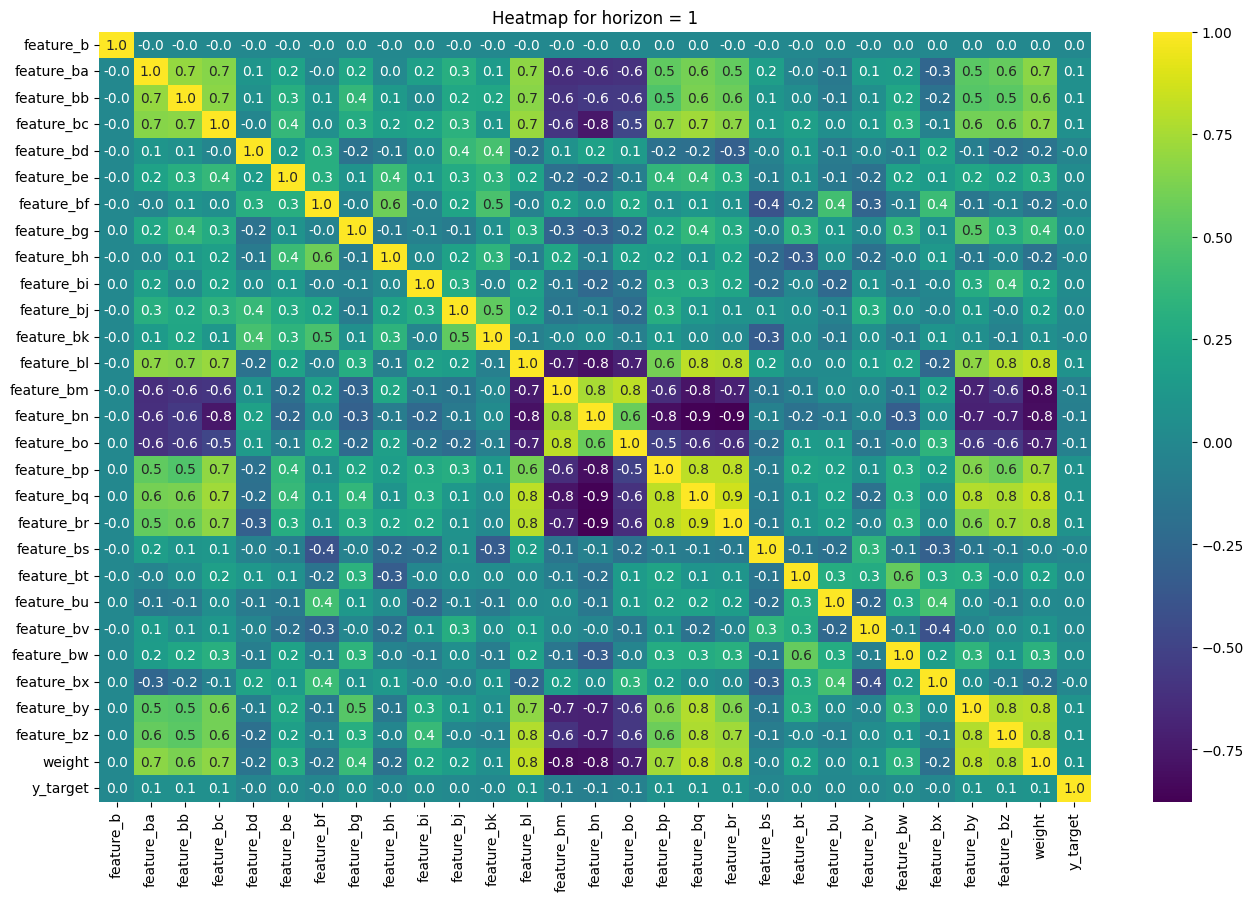

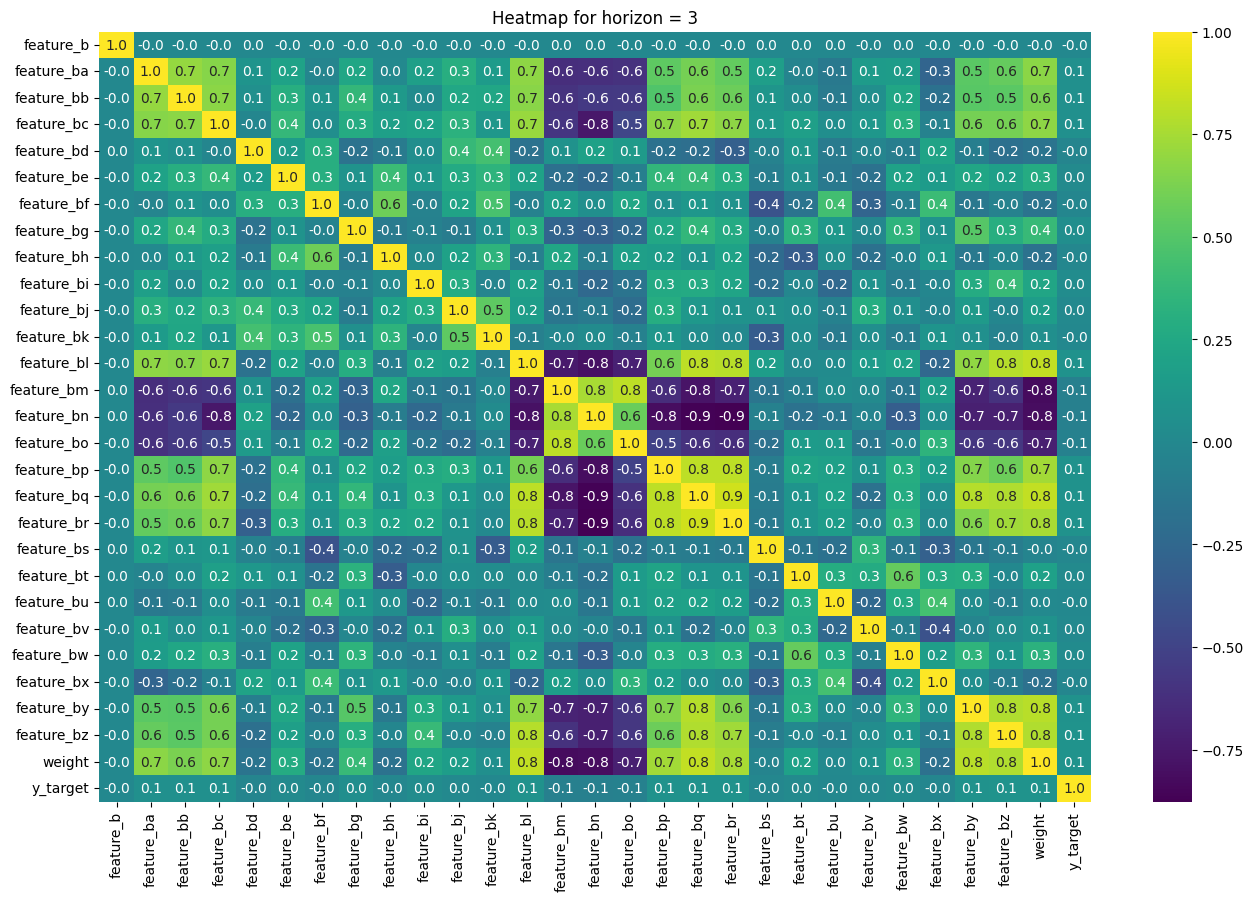

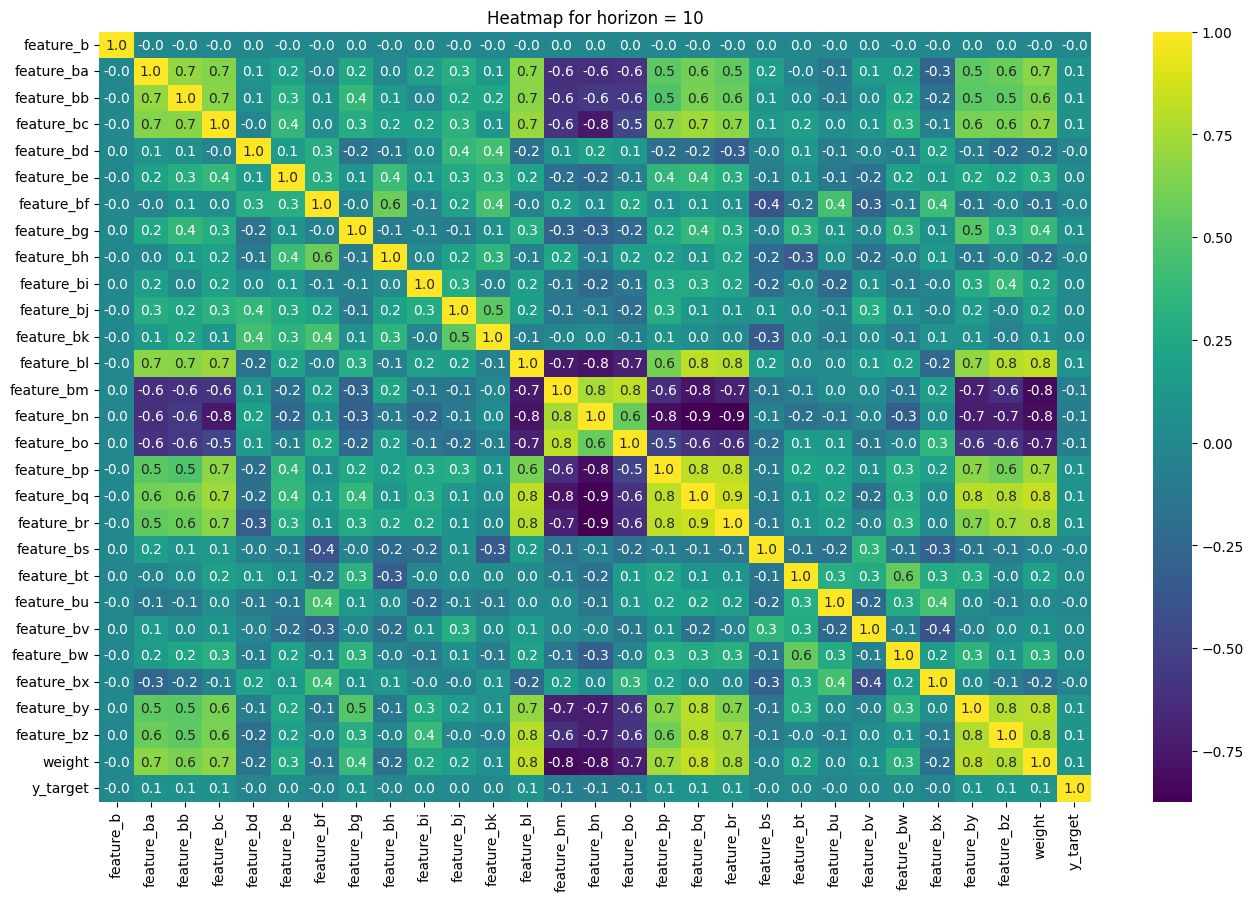

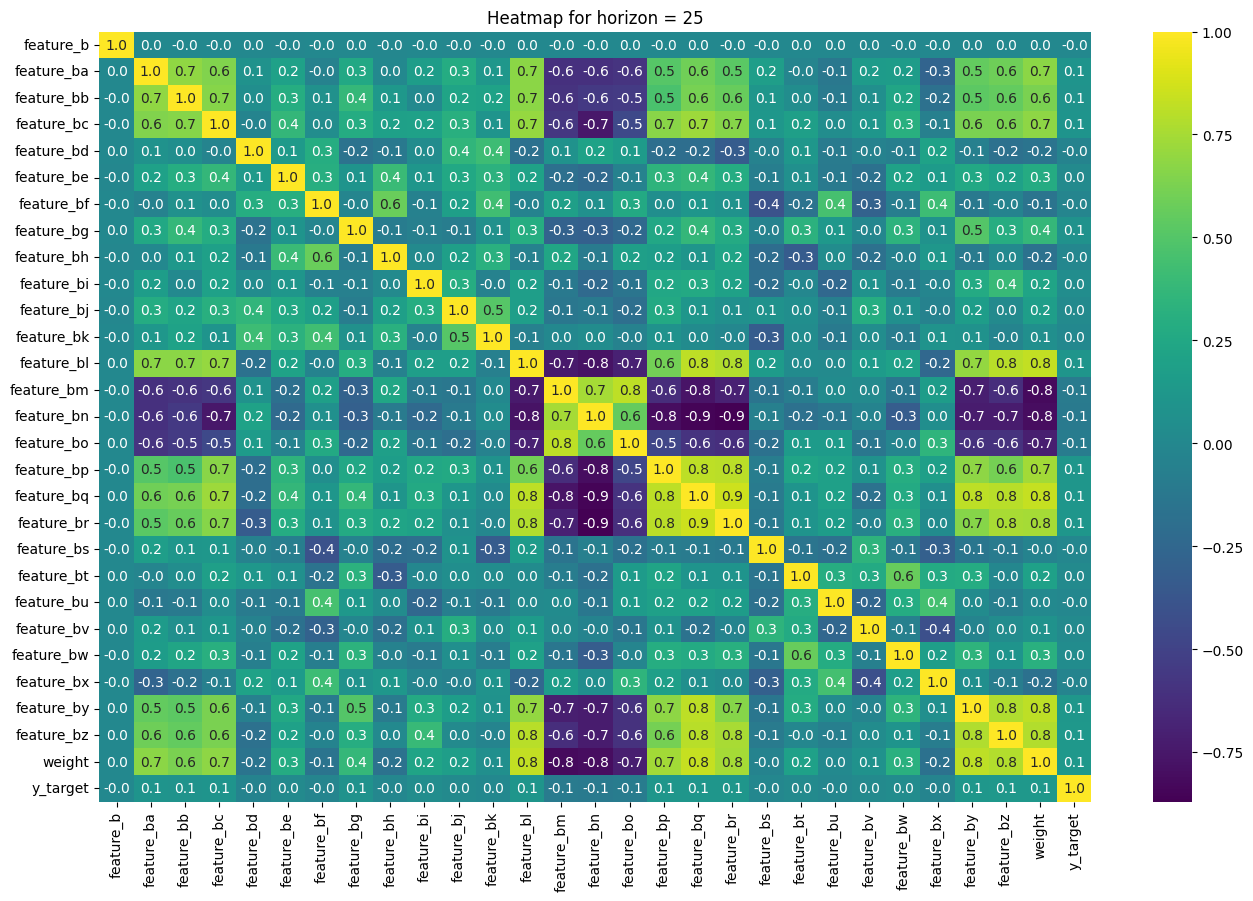

In [50]:
feature_b_df = split_df_according_to_patterns(df= corr_train_df, pattern="^feature_b")

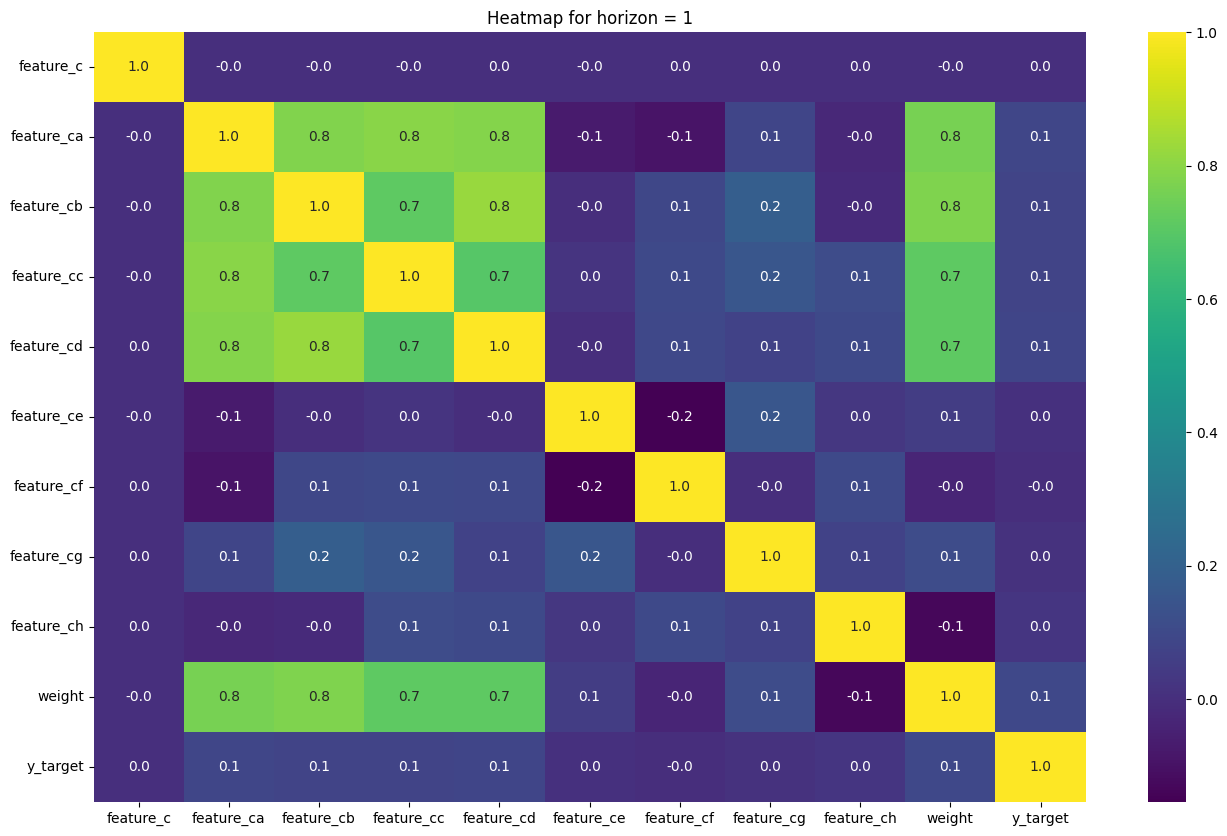

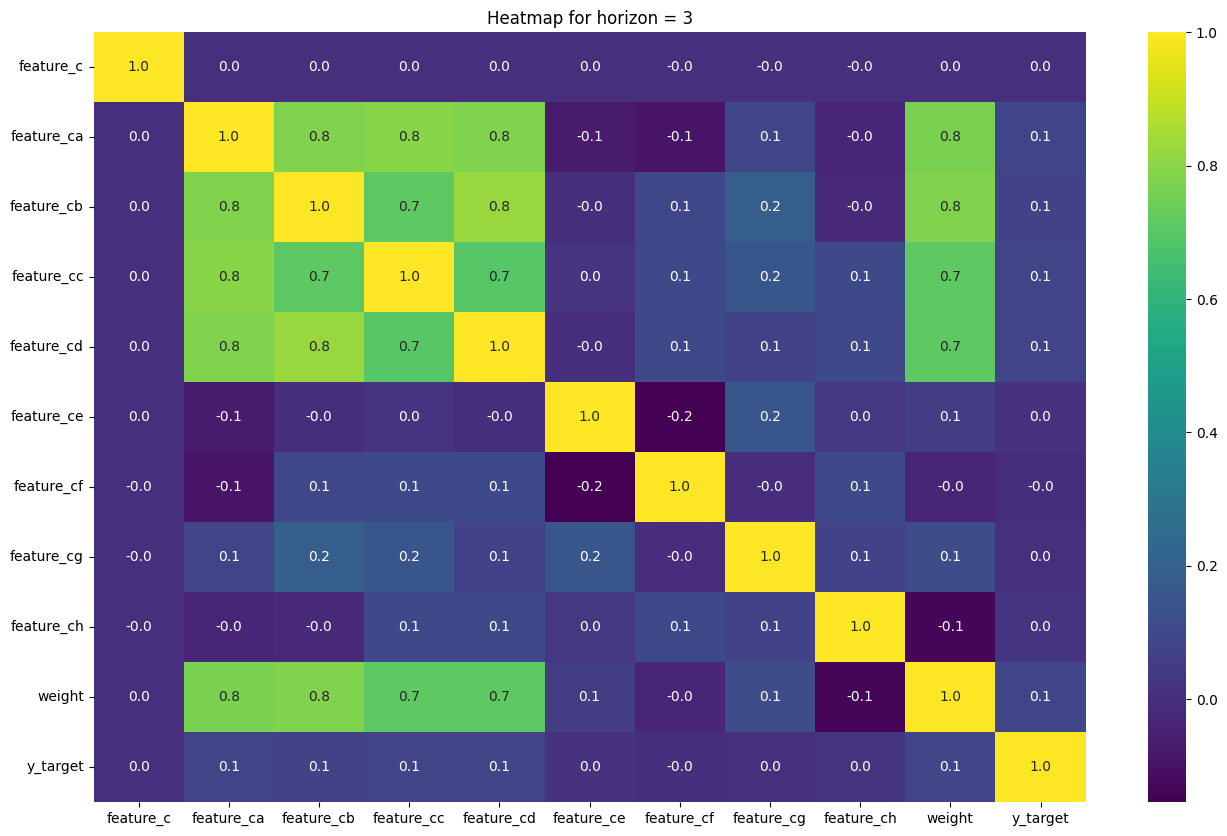

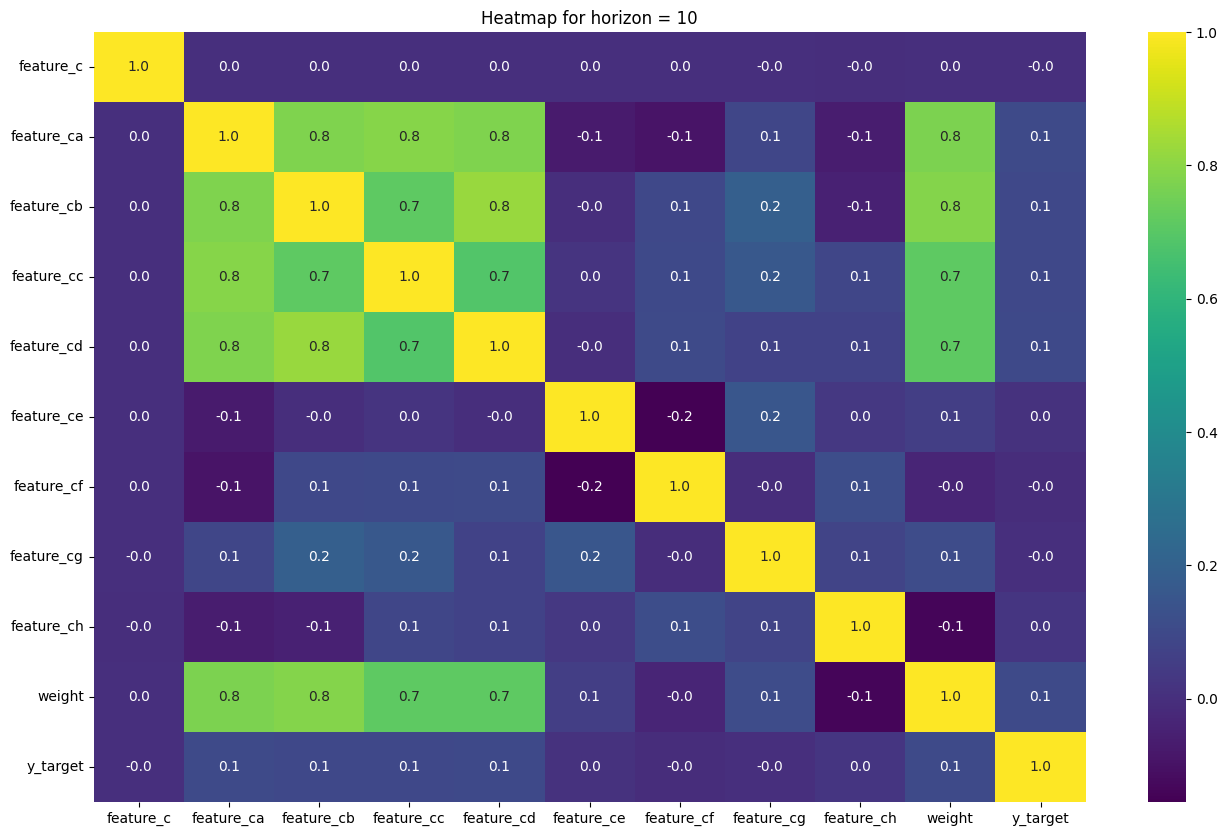

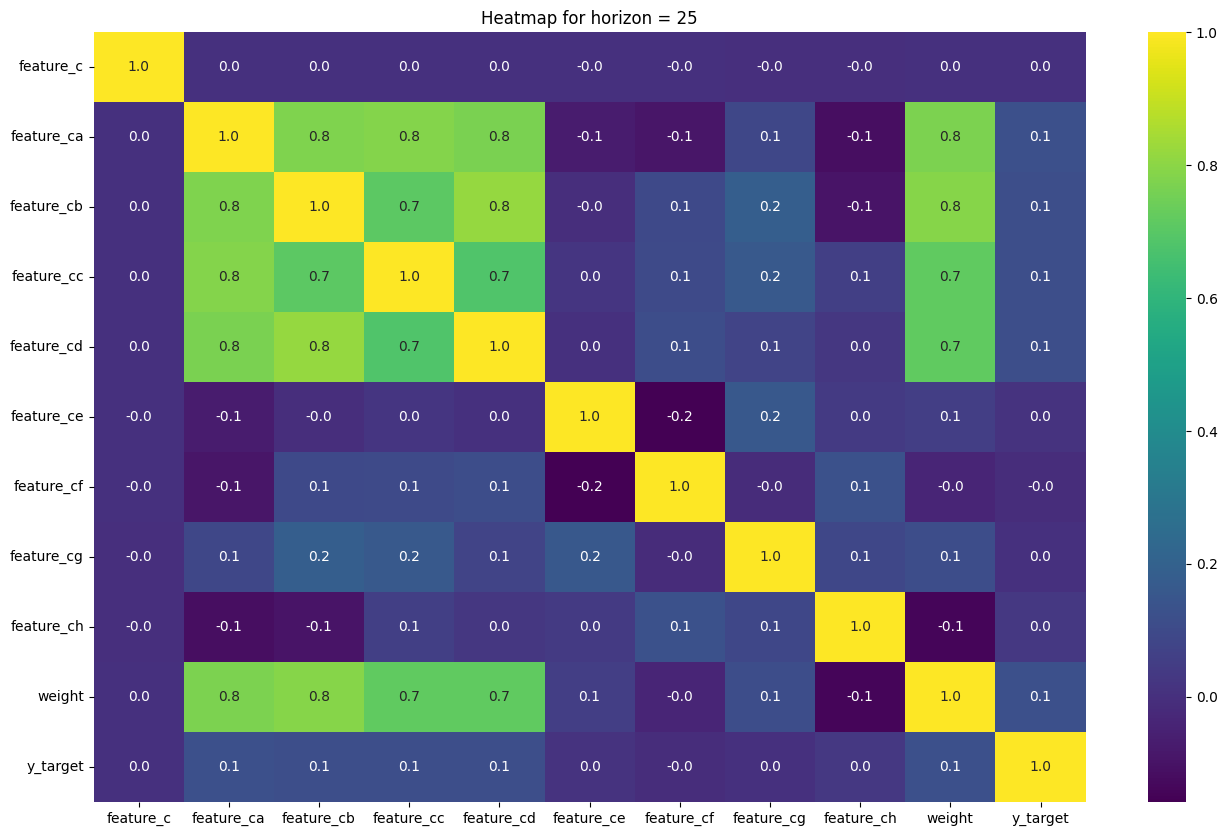

In [51]:
feature_c_df = split_df_according_to_patterns(df= corr_train_df, pattern="^feature_c")

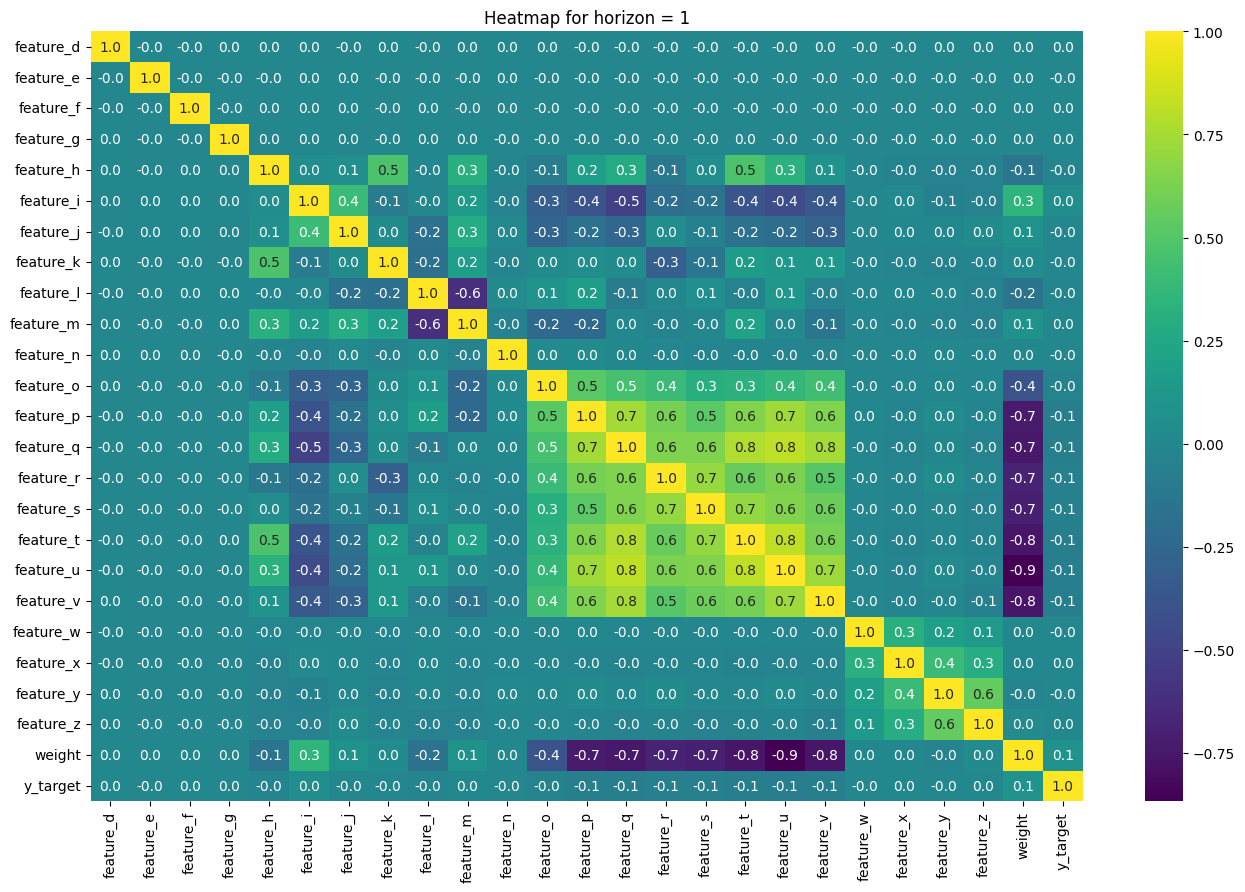

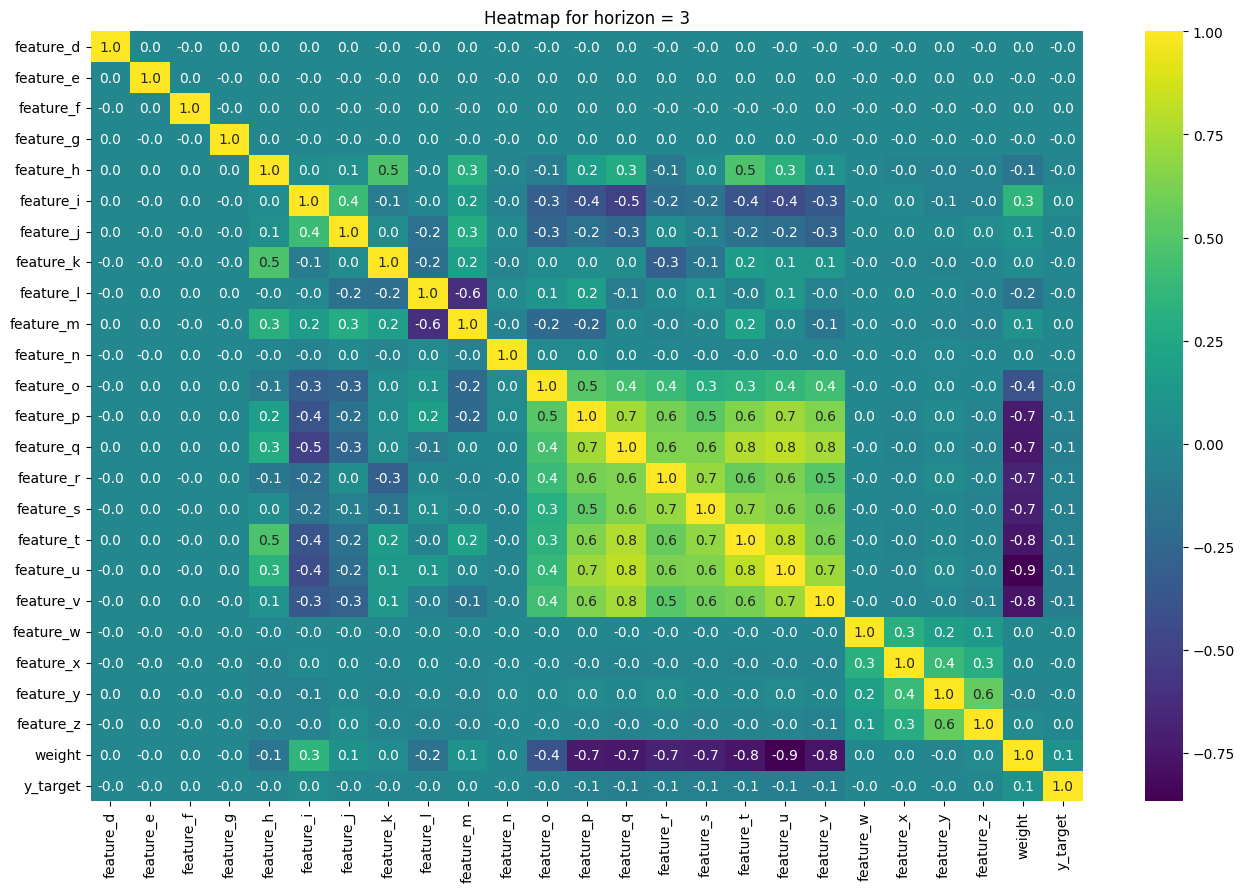

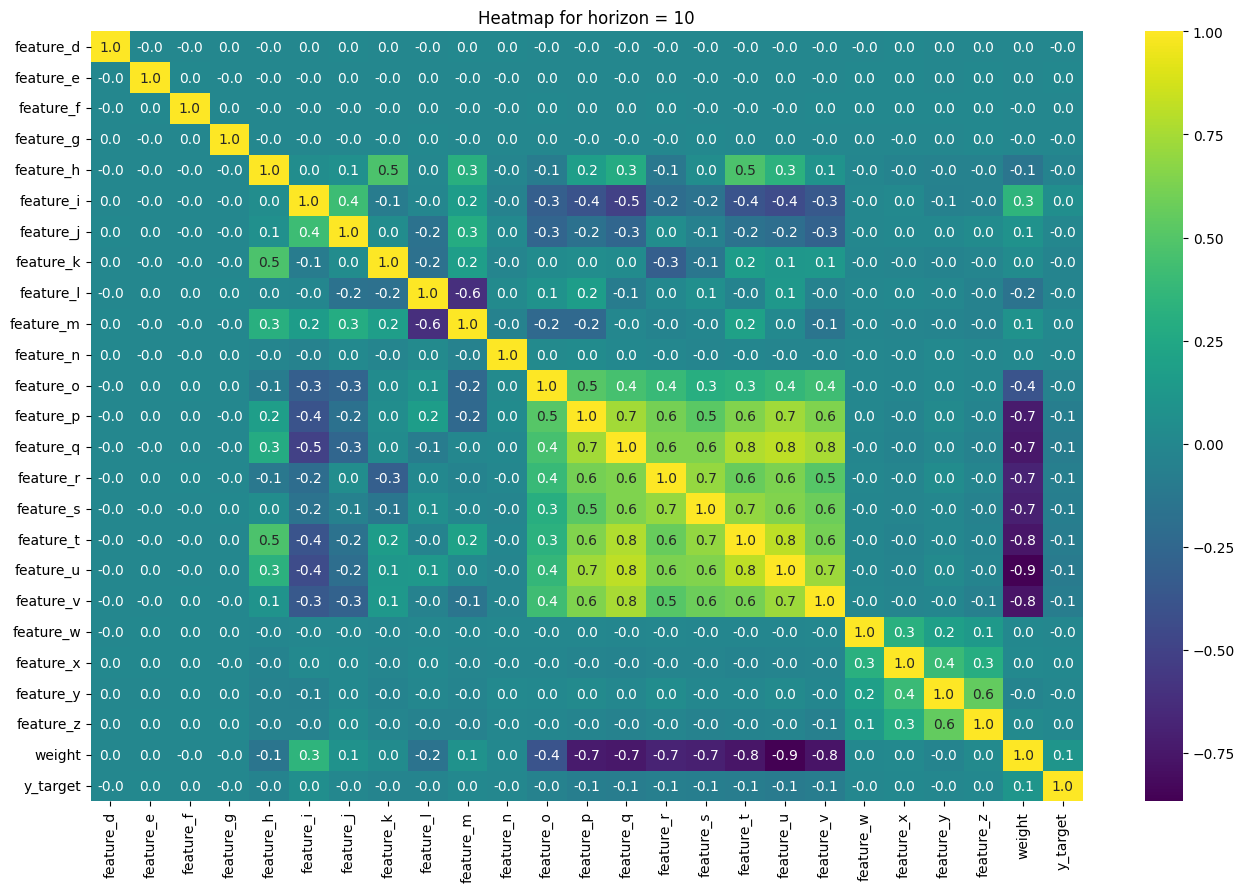

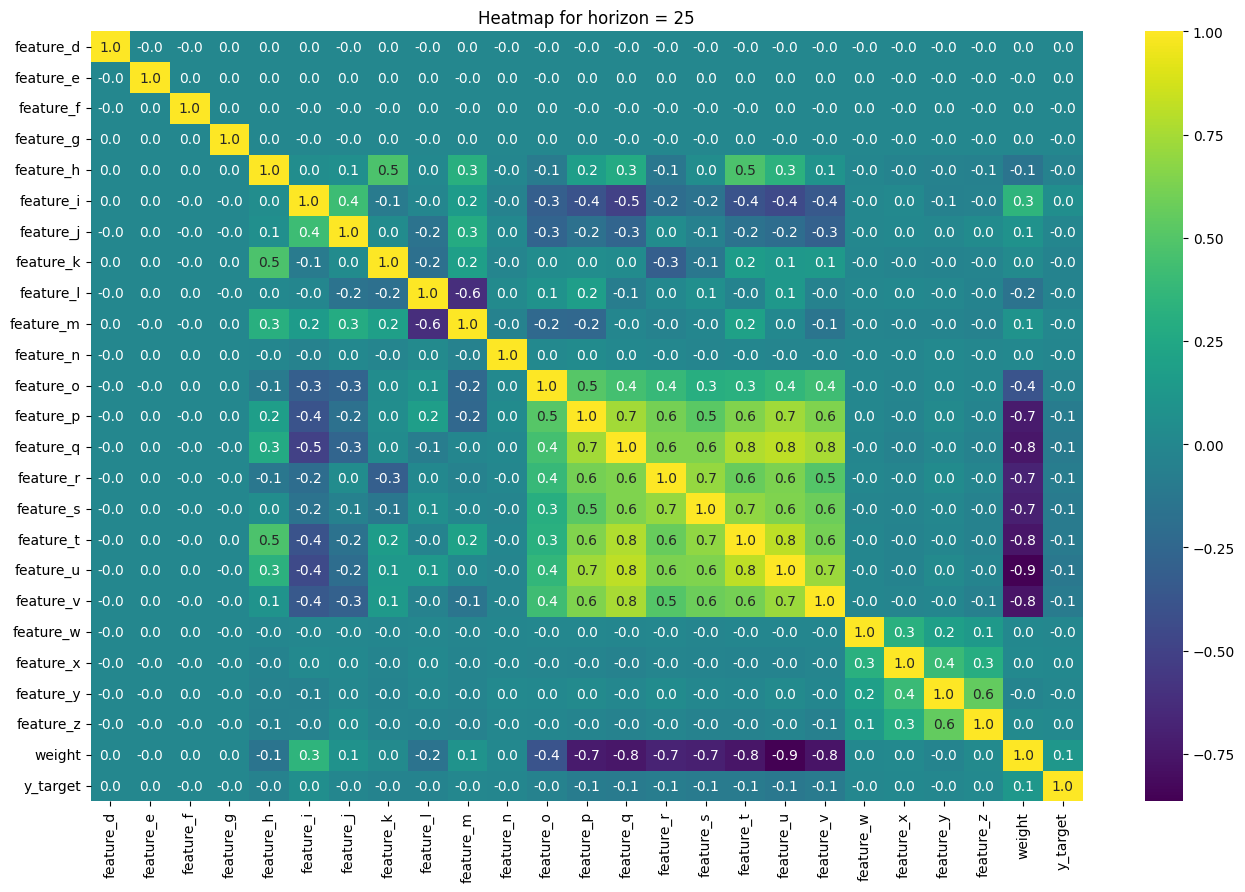

In [ ]:
feature_c_df = split_df_according_to_patterns(df= corr_train_df, pattern="^feature_(?!a|b|c)")

In [ ]:
corr = corr_train_df.corr(method="spearman")

weight_corr = corr["weight"].drop("weight")

feature_corr = corr.drop(["weight", "y_target", ""], axis=0).drop(["weight", "y_target"], axis=1)

In [99]:

features = [c for c in corr.columns if c not in ["weight", "y_target"]]
corr_features = corr.loc[features, features]

In [101]:
import numpy as np
import networkx as nx

pos_threshold = 0.7

adj_pos = (corr_features >= pos_threshold).astype(int)

# remove self loops
np.fill_diagonal(adj_pos.values, 0)

G_pos = nx.from_pandas_adjacency(adj_pos)

pos_groups = list(nx.connected_components(G_pos))

pos_groups


[{'horizon'},
 {'feature_a', 'feature_ch'},
 {'feature_b'},
 {'feature_c'},
 {'feature_d'},
 {'feature_e'},
 {'feature_f'},
 {'feature_g'},
 {'feature_h'},
 {'feature_i'},
 {'feature_j'},
 {'feature_k'},
 {'feature_l'},
 {'feature_m'},
 {'feature_n'},
 {'feature_o'},
 {'feature_ae',
  'feature_af',
  'feature_ag',
  'feature_am',
  'feature_an',
  'feature_ao',
  'feature_ap',
  'feature_bm',
  'feature_bn',
  'feature_bo',
  'feature_p',
  'feature_q',
  'feature_r',
  'feature_s',
  'feature_t',
  'feature_u',
  'feature_v'},
 {'feature_w'},
 {'feature_x'},
 {'feature_y'},
 {'feature_z'},
 {'feature_aa'},
 {'feature_ab'},
 {'feature_ac'},
 {'feature_ad'},
 {'feature_ah'},
 {'feature_ai'},
 {'feature_aj'},
 {'feature_ak'},
 {'feature_al'},
 {'feature_aq'},
 {'feature_ar'},
 {'feature_as'},
 {'feature_at'},
 {'feature_au'},
 {'feature_av', 'feature_bb'},
 {'feature_aw'},
 {'feature_ax'},
 {'feature_ay'},
 {'feature_az',
  'feature_bc',
  'feature_bl',
  'feature_bp',
  'feature_bq',
  

In [104]:
neg_threshold = -0.7

adj_neg = (corr_features <= neg_threshold).astype(int)

np.fill_diagonal(adj_neg.values, 0)

G_neg = nx.from_pandas_adjacency(adj_neg)

neg_groups = list(nx.connected_components(G_neg))

neg_groups


[{'horizon'},
 {'feature_a'},
 {'feature_b'},
 {'feature_c'},
 {'feature_d'},
 {'feature_e'},
 {'feature_f'},
 {'feature_g'},
 {'feature_h'},
 {'feature_i'},
 {'feature_j'},
 {'feature_k'},
 {'feature_l'},
 {'feature_m'},
 {'feature_n'},
 {'feature_o'},
 {'feature_af',
  'feature_ag',
  'feature_am',
  'feature_an',
  'feature_ao',
  'feature_ap',
  'feature_az',
  'feature_bc',
  'feature_bl',
  'feature_bm',
  'feature_bn',
  'feature_bo',
  'feature_bp',
  'feature_bq',
  'feature_br',
  'feature_by',
  'feature_bz',
  'feature_ca',
  'feature_cb',
  'feature_cc',
  'feature_cd',
  'feature_p',
  'feature_q',
  'feature_r',
  'feature_s',
  'feature_t',
  'feature_u',
  'feature_v'},
 {'feature_w'},
 {'feature_x'},
 {'feature_y'},
 {'feature_z'},
 {'feature_aa'},
 {'feature_ab'},
 {'feature_ac'},
 {'feature_ad'},
 {'feature_ae'},
 {'feature_ah'},
 {'feature_ai'},
 {'feature_aj'},
 {'feature_ak'},
 {'feature_al'},
 {'feature_aq'},
 {'feature_ar'},
 {'feature_as'},
 {'feature_at'},
 {

feature am, an, ao, ap, ae, af, ag, bm, bn, bo, p, q, r, s, t, u, v | negatively related to weights <br>
feature ba, bb, bc, av, bp, bq, br, by, bz, ca, cc, cd, ce | positively related to weights<br>
feature a, ch | positively related to weights

In [105]:
train_df['ts_index'].value_counts()

ts_index
2594    2039
2593    2030
2336    2029
2589    2022
2337    2019
        ... 
1805      95
1513      95
1380      80
798       69
608       60
Name: count, Length: 3601, dtype: int64

In [ ]:
train_df.sort_values(by='ts_index').head(100)

,id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,...,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
4501205,SJZP0OVU__SIJUOYMU__PZ9S1Z4V__10__1,SJZP0OVU,SIJUOYMU,PZ9S1Z4V,10,1,108,2.860736,1.708465,9.402990,...,-0.000436,-0.000024,-0.001493,-0.000467,0.003585,2.798858,2.145088,2,-0.000639,3.337224e+06
913598,660DZME0__CIED4XXN__PZ9S1Z4V__10__1,660DZME0,CIED4XXN,PZ9S1Z4V,10,1,176,2.128846,3.787317,4.762000,...,-0.021803,-0.930431,-0.038255,-0.499660,-0.214220,0.178657,0.127280,5,-2.037451,1.347645e+00
913597,660DZME0__CIED4XXN__PZ9S1Z4V__25__1,660DZME0,CIED4XXN,PZ9S1Z4V,25,1,161,14.888267,15.583904,14.473926,...,-0.021803,-0.930431,-0.038255,-0.499660,-0.214220,0.178657,0.127280,5,1.158949,3.860952e+00
3179057,MRV5UON2__JJKGJ8KH__PHHHVYZI__25__1,MRV5UON2,JJKGJ8KH,PHHHVYZI,25,1,127,8.702783,8.387899,5.749298,...,-0.000157,-0.000092,-0.001388,-0.000135,-0.003811,1.942079,3.580286,3,-0.159022,4.363430e+02
3179055,MRV5UON2__JJKGJ8KH__PHHHVYZI__3__1,MRV5UON2,JJKGJ8KH,PHHHVYZI,3,1,147,12.527648,3.544565,11.851244,...,-0.000157,-0.000092,-0.001388,-0.000135,-0.003811,1.942079,3.580286,3,-0.067769,1.061687e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1527871,W4S29LF4__SIJUOYMU__DPPUO5X2__25__1,W4S29LF4,SIJUOYMU,DPPUO5X2,25,1,84,5.453105,2.318513,11.851248,...,-0.086790,-0.140116,-0.155610,-5.651582,0.042704,0.047985,0.544150,2,90.954552,1.720195e-04
2604855,CXEQN6KB__7K0VPU0G__PZ9S1Z4V__25__1,CXEQN6KB,7K0VPU0G,PZ9S1Z4V,25,1,13,0.143911,10.227176,6.099595,...,-0.020045,-0.005753,-0.000655,-0.000840,-0.029835,4.513400,3.867542,0,0.776863,1.309483e+03
3089762,MRV5UON2__JJKGJ8KH__DPPUO5X2__10__1,MRV5UON2,JJKGJ8KH,DPPUO5X2,10,1,142,9.708046,2.450576,9.645892,...,-0.000157,-0.000092,-0.001388,-0.000135,-0.003811,1.942079,3.580286,3,-0.065153,1.833146e+03
3089761,MRV5UON2__JJKGJ8KH__DPPUO5X2__3__1,MRV5UON2,JJKGJ8KH,DPPUO5X2,3,1,149,13.277762,5.066071,13.691502,...,-0.000157,-0.000092,-0.001388,-0.000135,-0.003811,1.942079,3.580286,3,-0.046291,2.575489e+03


: 